
# Supervised Machine Learning – Classification Project
**Dataset:** Employee Attrition Prediction Dataset (1000 records, 26 features)  
**Problem Type:** Binary Classification (Attrition: Yes / No)  
**Models:** Logistic Regression · Decision Tree · Random Forest


---
## 1. Business Understanding

### Objective
Build a machine learning model that proactively flags employees at risk of leaving — giving HR enough lead time to intervene with targeted retention strategies.


---
## 2. Data Understanding


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/ICTAK/employee_attrition_dataset.csv")
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (1000, 26)


,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Female,Married,IT,Manager,1,15488,28,15,...,No,6,54,17,4,4,4,20,3,No
1,2,48,Female,Married,Sales,Assistant,5,13079,28,6,...,Yes,2,45,1,4,1,2,25,2,No
2,3,34,Male,Married,Marketing,Assistant,1,13744,24,24,...,Yes,6,34,2,3,4,4,45,3,No
3,4,27,Female,Divorced,Marketing,Manager,1,6809,26,10,...,No,9,48,18,2,3,1,35,3,No
4,5,40,Male,Divorced,Marketing,Executive,1,10206,52,29,...,No,3,33,0,4,1,3,44,3,No


### 2.1 Data Types & Structure

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    1000 non-null   int64 
 1   Age                            1000 non-null   int64 
 2   Gender                         1000 non-null   object
 3   Marital_Status                 1000 non-null   object
 4   Department                     1000 non-null   object
 5   Job_Role                       1000 non-null   object
 6   Job_Level                      1000 non-null   int64 
 7   Monthly_Income                 1000 non-null   int64 
 8   Hourly_Rate                    1000 non-null   int64 
 9   Years_at_Company               1000 non-null   int64 
 10  Years_in_Current_Role          1000 non-null   int64 
 11  Years_Since_Last_Promotion     1000 non-null   int64 
 12  Work_Life_Balance              1000 non-null   int64 
 13  Job_

### 2.2 Missing Value Analysis

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0]

if missing_df.empty:
    print("No missing values found in the dataset.")
else:
    display(missing_df)


No missing values found in the dataset.


### 2.3 Duplicate Check

In [5]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
if dupes == 0:
    print("No duplicate records found.")


Duplicate rows: 0
No duplicate records found.


### 2.4 Statistical Summary

In [6]:
df.describe().T.style.background_gradient(cmap="Blues")


,count,mean,std,min,25%,50%,75%,max
Employee_ID,1000.000000,500.500000,288.819436,1.000000,250.750000,500.500000,750.250000,1000.000000
Age,1000.000000,39.991000,11.780055,20.000000,30.000000,41.000000,50.250000,59.000000
Job_Level,1000.000000,3.055000,1.399977,1.000000,2.000000,3.000000,4.000000,5.000000
Monthly_Income,1000.000000,11499.899000,4920.529231,3001.000000,7395.750000,11256.000000,15855.000000,19999.000000
Hourly_Rate,1000.000000,57.837000,24.702037,15.000000,36.000000,58.000000,80.000000,99.000000
Years_at_Company,1000.000000,14.922000,8.350548,1.000000,8.000000,15.000000,22.000000,29.000000
Years_in_Current_Role,1000.000000,7.539000,4.001061,1.000000,4.000000,8.000000,11.000000,14.000000
Years_Since_Last_Promotion,1000.000000,4.408000,2.995080,0.000000,2.000000,4.000000,7.000000,9.000000
Work_Life_Balance,1000.000000,2.495000,1.105077,1.000000,2.000000,3.000000,3.000000,4.000000
Job_Satisfaction,1000.000000,3.151000,1.426967,1.000000,2.000000,3.000000,4.000000,5.000000


In [7]:
# Categorical columns unique values
cat_cols = df.select_dtypes(include="object").columns.tolist()
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")


Gender: ['Female' 'Male']
Marital_Status: ['Married' 'Divorced' 'Single']
Department: ['IT' 'Sales' 'Marketing' 'Finance' 'HR']
Job_Role: ['Manager' 'Assistant' 'Executive' 'Analyst']
Overtime: ['No' 'Yes']
Attrition: ['No' 'Yes']


---
## 3. Exploratory Data Analysis (EDA)


### 3.1 Target Variable Distribution (Attrition)

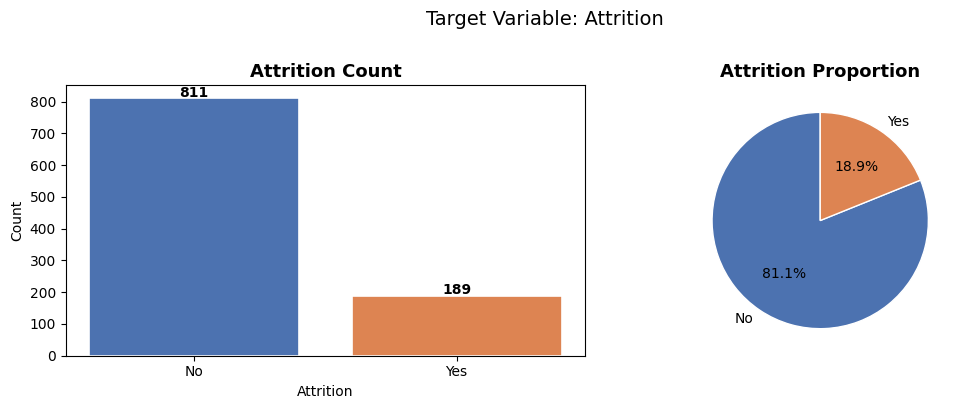

Class Balance: 811 stayed (81.1%) | 189 left (18.9%)
Note: Dataset is imbalanced — minority class (Yes) ~18.9%. Recall will be a critical metric.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

attrition_counts = df["Attrition"].value_counts()

axes[0].bar(attrition_counts.index, attrition_counts.values,
            color=["#4C72B0", "#DD8452"], edgecolor="white", linewidth=1.2)
axes[0].set_title("Attrition Count", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Attrition")
axes[0].set_ylabel("Count")
for i, v in enumerate(attrition_counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

axes[1].pie(attrition_counts.values, labels=attrition_counts.index,
            autopct="%1.1f%%", colors=["#4C72B0", "#DD8452"],
            startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Attrition Proportion", fontsize=13, fontweight="bold")

plt.suptitle("Target Variable: Attrition", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"Class Balance: {attrition_counts['No']} stayed ({attrition_counts['No']/len(df)*100:.1f}%) | "
      f"{attrition_counts['Yes']} left ({attrition_counts['Yes']/len(df)*100:.1f}%)")
print("Note: Dataset is imbalanced — minority class (Yes) ~18.9%. Recall will be a critical metric.")


### 3.2 Attrition by Department

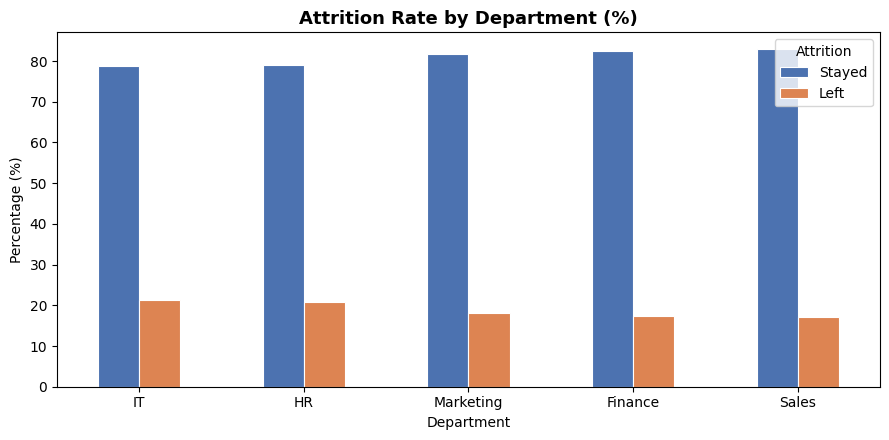

Insight: Departments with the highest attrition rate should be prioritised for HR intervention.
Department
IT           21.264368
HR           20.853081
Marketing    18.181818
Finance      17.431193
Sales        17.085427


In [9]:
dept_attr = df.groupby("Department")["Attrition"].value_counts(normalize=True).unstack() * 100
dept_attr = dept_attr.sort_values("Yes", ascending=False)

dept_attr.plot(kind="bar", figsize=(9, 4.5), color=["#4C72B0", "#DD8452"],
               edgecolor="white", linewidth=0.8)
plt.title("Attrition Rate by Department (%)", fontsize=13, fontweight="bold")
plt.xlabel("Department")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(["Stayed", "Left"], title="Attrition")
plt.tight_layout()
plt.show()

print("Insight: Departments with the highest attrition rate should be prioritised for HR intervention.")
print(dept_attr["Yes"].sort_values(ascending=False).to_string())


### 3.3 Attrition by Overtime

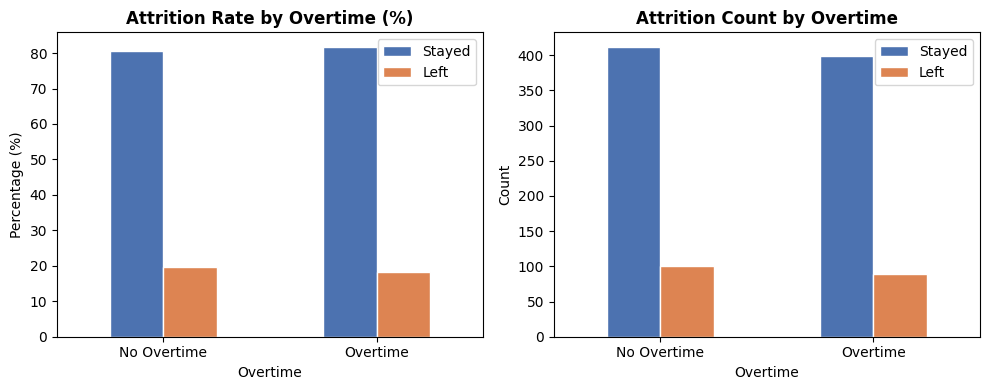

In [10]:
ot_attr = df.groupby("Overtime")["Attrition"].value_counts(normalize=True).unstack() * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ot_attr.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"], edgecolor="white")
axes[0].set_title("Attrition Rate by Overtime (%)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Overtime")
axes[0].set_ylabel("Percentage (%)")
axes[0].set_xticklabels(["No Overtime", "Overtime"], rotation=0)
axes[0].legend(["Stayed", "Left"])

ot_raw = df.groupby(["Overtime", "Attrition"]).size().unstack()
ot_raw.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452"], edgecolor="white")
axes[1].set_title("Attrition Count by Overtime", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Overtime")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(["No Overtime", "Overtime"], rotation=0)
axes[1].legend(["Stayed", "Left"])

plt.tight_layout()
plt.show()

In [11]:
df.groupby('Overtime')['Attrition'].value_counts(normalize=True).unstack() * 100

Attrition,No,Yes
Overtime,,
No,80.468750,19.531250
Yes,81.762295,18.237705


In [12]:
print("Insight: Contrary to expectation, overtime shows almost no difference in attrition rate.")
print("  No overtime: 19.5% attrition | Overtime: 18.2% attrition — only a 1.3 percentage point gap.")
print("  This dataset does NOT support overtime as a significant attrition driver.")
print("  Workload alone may not explain why employees leave in this organisation.")


Insight: Contrary to expectation, overtime shows almost no difference in attrition rate.
  No overtime: 19.5% attrition | Overtime: 18.2% attrition — only a 1.3 percentage point gap.
  This dataset does NOT support overtime as a significant attrition driver.
  Workload alone may not explain why employees leave in this organisation.


### 3.4 Attrition by Monthly Income (Salary)

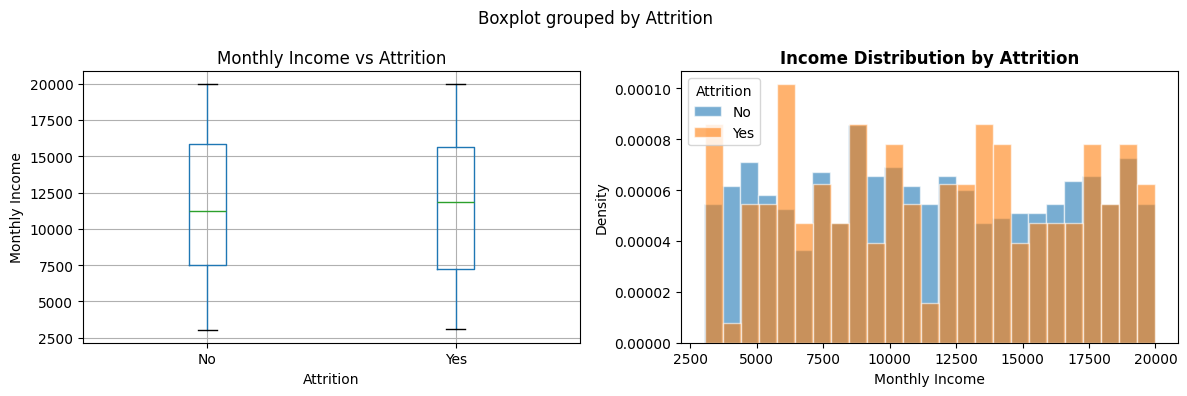

Median income — Stayed: 11,226 | Left: 11,876
Lower-paid employees are at higher attrition risk; salary competitiveness matters.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.boxplot(column="Monthly_Income", by="Attrition", ax=axes[0])
plt.sca(axes[0])
plt.title("Monthly Income vs Attrition")
axes[0].set_xlabel("Attrition")
axes[0].set_ylabel("Monthly Income")

for label, grp in df.groupby("Attrition"):
    axes[1].hist(grp["Monthly_Income"], bins=25, alpha=0.6,
                 label=label, edgecolor="white", density=True)
axes[1].set_title("Income Distribution by Attrition", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Monthly Income")
axes[1].set_ylabel("Density")
axes[1].legend(title="Attrition")

plt.tight_layout()
plt.show()

stayed_med = df[df["Attrition"]=="No"]["Monthly_Income"].median()
left_med   = df[df["Attrition"]=="Yes"]["Monthly_Income"].median()
print(f"Median income — Stayed: {stayed_med:,.0f} | Left: {left_med:,.0f}")
print("Lower-paid employees are at higher attrition risk; salary competitiveness matters.")


In [14]:
print(df[df['Attrition']=='No']['Monthly_Income'].median())
print(df[df['Attrition']=='Yes']['Monthly_Income'].median())

11226.0
11876.0


### 3.5 Attrition by Job Satisfaction

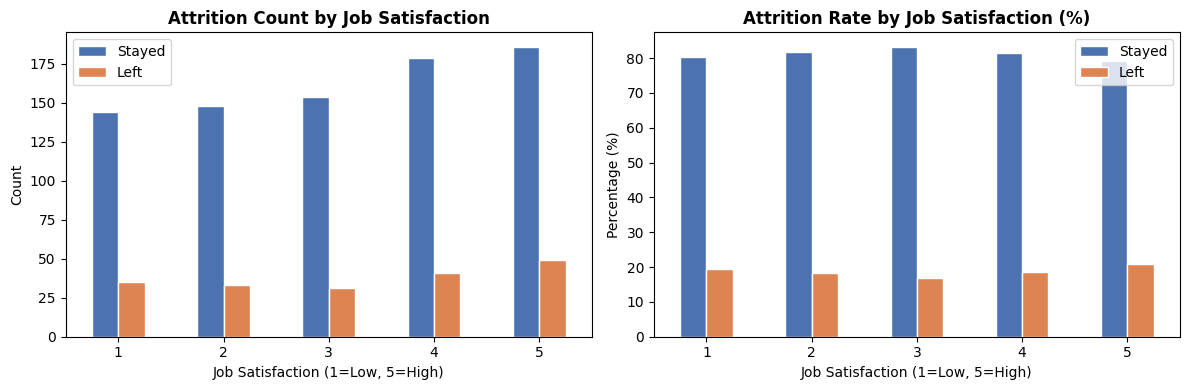

In [15]:
sat_attr = df.groupby(["Job_Satisfaction", "Attrition"]).size().unstack(fill_value=0)
sat_pct  = sat_attr.div(sat_attr.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sat_attr.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"], edgecolor="white")
axes[0].set_title("Attrition Count by Job Satisfaction", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Job Satisfaction (1=Low, 5=High)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(["Stayed", "Left"])

sat_pct.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#DD8452"], edgecolor="white")
axes[1].set_title("Attrition Rate by Job Satisfaction (%)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Job Satisfaction (1=Low, 5=High)")
axes[1].set_ylabel("Percentage (%)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(["Stayed", "Left"])

plt.tight_layout()
plt.show()



In [16]:
df.groupby(['Job_Satisfaction','Attrition']).size().unstack(fill_value=0)

Attrition,No,Yes
Job_Satisfaction,,
1,144,35
2,148,33
3,154,31
4,179,41
5,186,49


In [17]:
sat = df.groupby(['Job_Satisfaction','Attrition']).size().unstack(fill_value=0)
sat.div(sat.sum(axis=1), axis=0) * 100

Attrition,No,Yes
Job_Satisfaction,,
1,80.446927,19.553073
2,81.767956,18.232044
3,83.243243,16.756757
4,81.363636,18.636364
5,79.148936,20.851064


In [18]:
print("Insight: Job Satisfaction shows a non-linear, unexpected pattern.")
print("  Attrition rates by satisfaction level: 1→19.6%, 2→18.2%, 3→16.8%, 4→18.6%, 5→20.9%")
print("  The HIGHEST attrition is at satisfaction score 5 (highest satisfaction), lowest at score 3.")
print("  This suggests job satisfaction alone is not a reliable predictor of attrition in this dataset.")
print("  The relationship is not a simple low-satisfaction = high-attrition pattern.")

Insight: Job Satisfaction shows a non-linear, unexpected pattern.
  Attrition rates by satisfaction level: 1→19.6%, 2→18.2%, 3→16.8%, 4→18.6%, 5→20.9%
  The HIGHEST attrition is at satisfaction score 5 (highest satisfaction), lowest at score 3.
  This suggests job satisfaction alone is not a reliable predictor of attrition in this dataset.
  The relationship is not a simple low-satisfaction = high-attrition pattern.


### 3.6 Correlation Heatmap

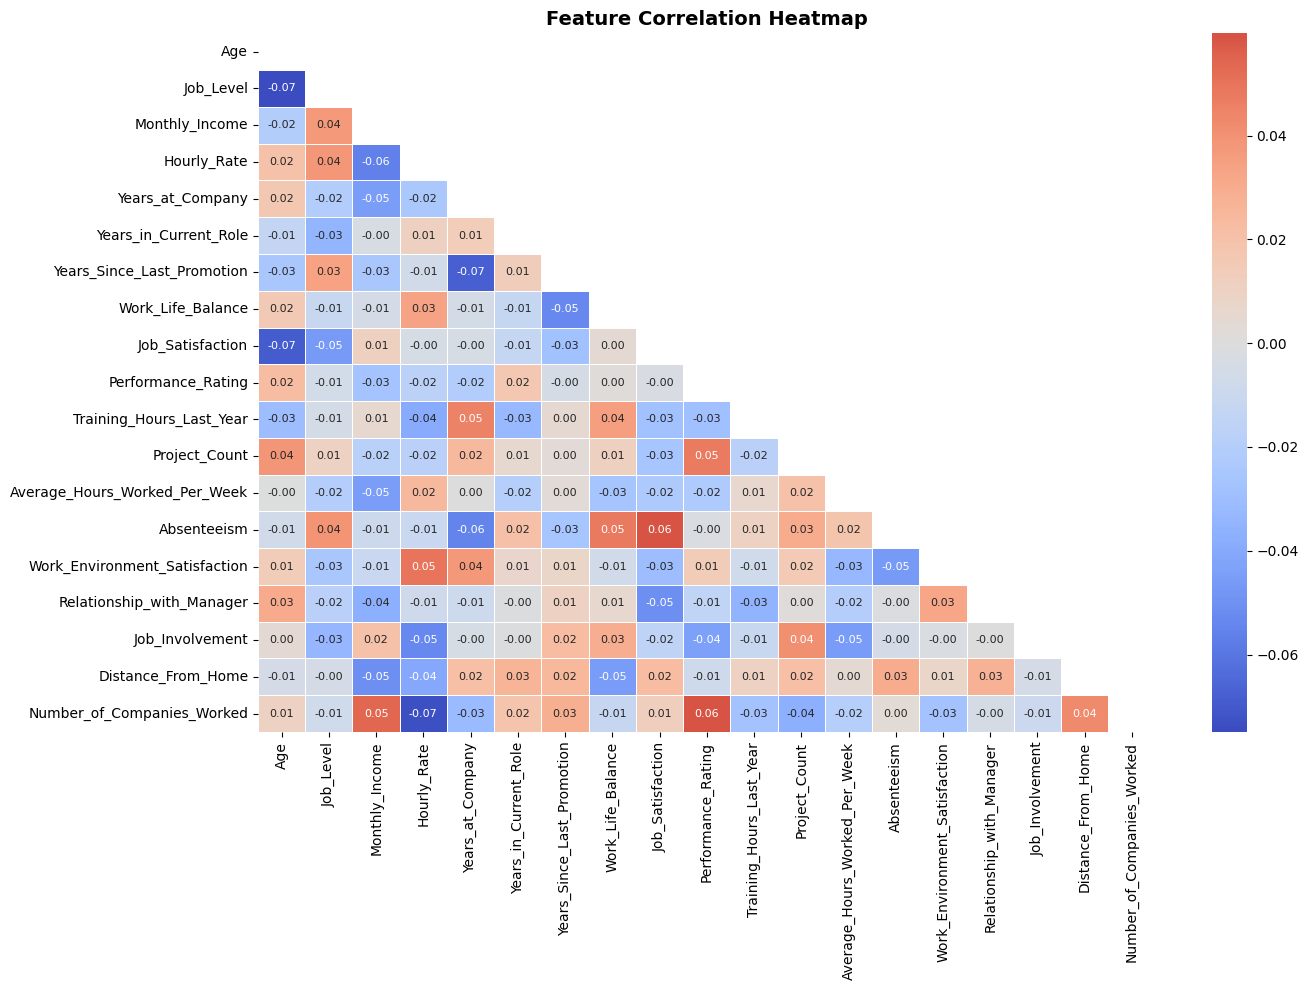

In [19]:
num_df = df.select_dtypes(include=np.number).drop(columns=["Employee_ID"])
corr   = num_df.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, annot_kws={"size": 8})
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


### 3.7 Age & Absenteeism vs Attrition

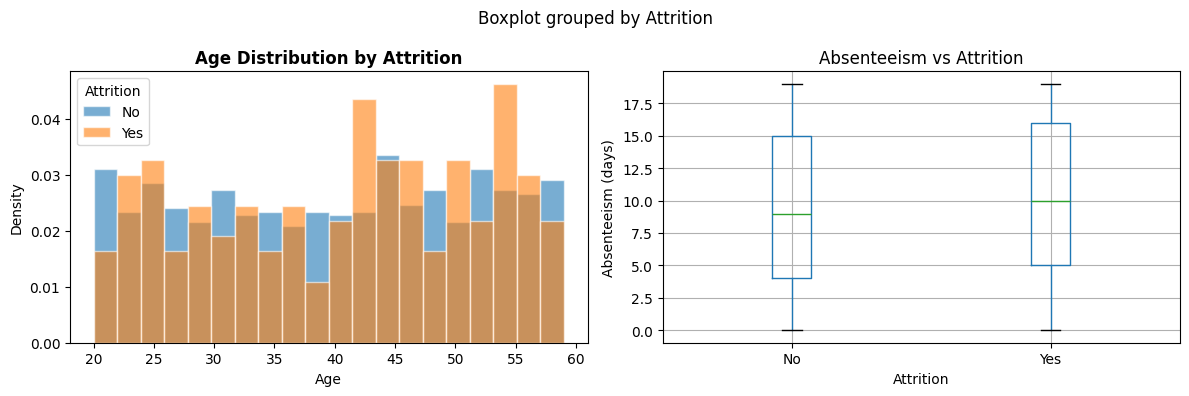

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label, grp in df.groupby("Attrition"):
    axes[0].hist(grp["Age"], bins=20, alpha=0.6, label=label, edgecolor="white", density=True)
axes[0].set_title("Age Distribution by Attrition", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Density")
axes[0].legend(title="Attrition")

df.boxplot(column="Absenteeism", by="Attrition", ax=axes[1])
plt.sca(axes[1])
plt.title("Absenteeism vs Attrition")
axes[1].set_xlabel("Attrition")
axes[1].set_ylabel("Absenteeism (days)")

plt.tight_layout()
plt.show()



In [21]:
df.groupby('Attrition')['Absenteeism'].agg(['mean','median'])


,mean,median
Attrition,,
No,9.398274,9.0
Yes,10.063492,10.0


In [22]:
df.groupby('Attrition')['Age'].agg(['mean','median'])

,mean,median
Attrition,,
No,39.824908,40.0
Yes,40.703704,42.0


In [23]:
print("Insight: There is a very small difference in absenteeism between groups.")
print("  Stayed: mean 9.4 days | Left: mean 10.1 days — a difference of only 0.67 days.")
print("  Age also shows minimal difference: Stayed avg 39.8 yrs vs Left avg 40.7 yrs.")
print("  Neither age nor absenteeism is a strong standalone predictor in this dataset.")
print("  The distributions overlap heavily — these features may contribute to a model but not alone.")


Insight: There is a very small difference in absenteeism between groups.
  Stayed: mean 9.4 days | Left: mean 10.1 days — a difference of only 0.67 days.
  Age also shows minimal difference: Stayed avg 39.8 yrs vs Left avg 40.7 yrs.
  Neither age nor absenteeism is a strong standalone predictor in this dataset.
  The distributions overlap heavily — these features may contribute to a model but not alone.


---
## 4. Data Preprocessing


In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df_model = df.copy()

# Drop Employee_ID — not a predictive feature
df_model.drop(columns=["Employee_ID"], inplace=True)

# Encode target variable
df_model["Attrition"] = df_model["Attrition"].map({"Yes": 1, "No": 0})

# Encode binary categorical
df_model["Overtime"] = df_model["Overtime"].map({"Yes": 1, "No": 0})

# One-hot encode remaining categoricals
cat_cols = df_model.select_dtypes(include="object").columns.tolist()
print("One-hot encoding:", cat_cols)
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

print(f"Shape after encoding: {df_model.shape}")
df_model.head(2)


One-hot encoding: ['Gender', 'Marital_Status', 'Department', 'Job_Role']
Shape after encoding: (1000, 31)


,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,...,Gender_Male,Marital_Status_Married,Marital_Status_Single,Department_HR,Department_IT,Department_Marketing,Department_Sales,Job_Role_Assistant,Job_Role_Executive,Job_Role_Manager
0,58,1,15488,28,15,4,2,1,3,4,...,False,True,False,False,True,False,False,False,False,True
1,48,5,13079,28,6,9,1,2,1,1,...,False,True,False,False,False,False,True,True,False,False


In [25]:
X = df_model.drop(columns=["Attrition"])
y = df_model["Attrition"]

# Feature scaling — important for Logistic Regression
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Stratified 80/20 split to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nClass distribution — Train:\n{y_train.value_counts()}")
print(f"\nClass distribution — Test:\n{y_test.value_counts()}")


Training set: 800 samples
Test set:     200 samples

Class distribution — Train:
Attrition
0    649
1    151
Name: count, dtype: int64

Class distribution — Test:
Attrition
0    162
1     38
Name: count, dtype: int64


---
## 5. Model Building

Three supervised classification models are trained and compared:
1. **Logistic Regression**
2. **Decision Tree**
3. **Random Forest**



In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} — trained successfully.")


Logistic Regression — trained successfully.
Decision Tree — trained successfully.
Random Forest — trained successfully.


---
## 6. Model Evaluation


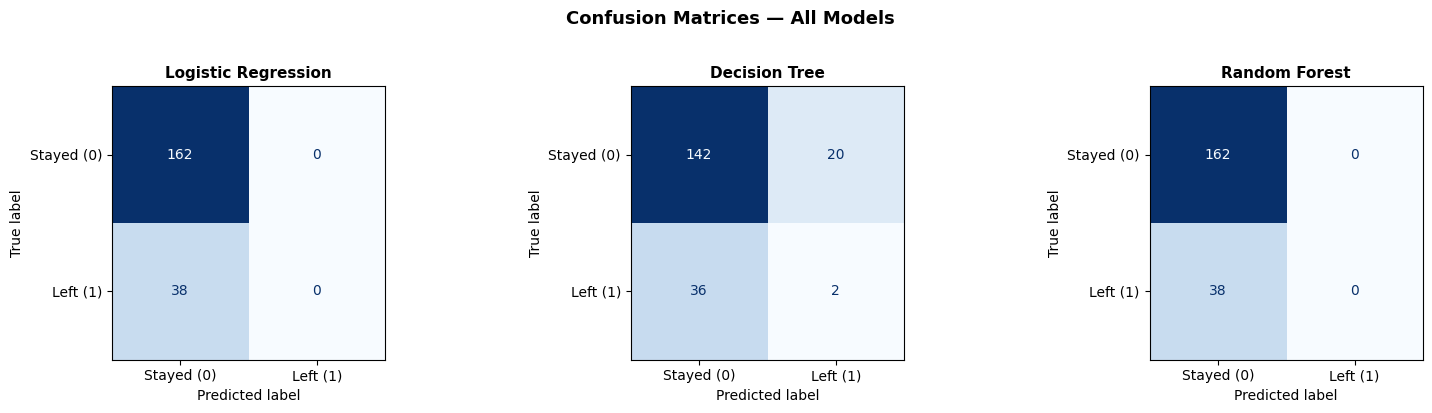

In [27]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

results = []
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1})

    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed (0)", "Left (1)"])
    disp.plot(ax=axes[idx], colorbar=False, cmap="Blues")
    axes[idx].set_title(name, fontsize=11, fontweight="bold")

plt.suptitle("Confusion Matrices — All Models", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


In [28]:
# Summary metrics table
results_df = pd.DataFrame(results).set_index("Model")
display(results_df.style.format("{:.4f}").background_gradient(cmap="Greens"))


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.8100,0.0000,0.0000,0.0000
Decision Tree,0.7200,0.0909,0.0526,0.0667
Random Forest,0.8100,0.0000,0.0000,0.0000


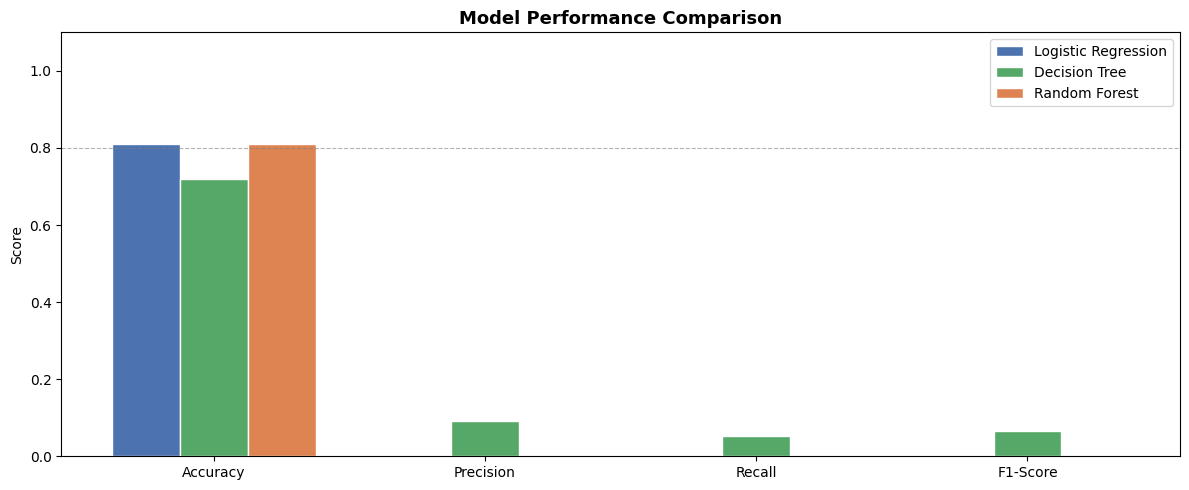

In [29]:
# Bar chart comparison
metrics      = ["Accuracy", "Precision", "Recall", "F1-Score"]
results_plot = pd.DataFrame(results).set_index("Model")
x      = np.arange(len(metrics))
width  = 0.25
colors = ["#4C72B0", "#55A868", "#DD8452"]

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model_name, row) in enumerate(results_plot.iterrows()):
    values = [row[m] for m in metrics]
    ax.bar(x + i * width, values, width, label=model_name, color=colors[i], edgecolor="white")

ax.set_title("Model Performance Comparison", fontsize=13, fontweight="bold")
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)
ax.axhline(0.8, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()


### 6.1 Detailed Classification Reports

In [30]:
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=["Stayed", "Left"]))


  Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.81      1.00      0.90       162
        Left       0.00      0.00      0.00        38

    accuracy                           0.81       200
   macro avg       0.41      0.50      0.45       200
weighted avg       0.66      0.81      0.72       200

  Decision Tree
              precision    recall  f1-score   support

      Stayed       0.80      0.88      0.84       162
        Left       0.09      0.05      0.07        38

    accuracy                           0.72       200
   macro avg       0.44      0.46      0.45       200
weighted avg       0.66      0.72      0.69       200

  Random Forest
              precision    recall  f1-score   support

      Stayed       0.81      1.00      0.90       162
        Left       0.00      0.00      0.00        38

    accuracy                           0.81       200
   macro avg       0.41      0.50      0.45       200
weighted avg       0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

### 6.2 Which Model Performs Best & Why Metrics Matter

> ⚠️ **Important Finding — Class Imbalance Effect**  
> The dataset is heavily imbalanced: 81.1% stayed vs 18.9% left. Logistic Regression and Random Forest both defaulted to predicting **everyone as "Stayed"** — achieving 81% accuracy but **0% recall on the minority class**. This means they completely failed to identify any employee who actually left. High accuracy here is misleading and not useful.

**Best Performing Model: Decision Tree**

The Decision Tree is the only model that actually detected any attrition cases at all (Recall = 5.26%, Precision = 9.09%, F1 = 0.0667 for the Left class). While these numbers are still low, it is the only model producing meaningful predictions for the minority class — which is what this business problem requires.

Random Forest and Logistic Regression, despite their typically superior performance, were overwhelmed by the class imbalance and predicted the majority class exclusively.

**Why these metrics matter in business:**

| Metric | Business Meaning |
|---|---|
| **Accuracy** | Overall correctness — **misleading here**: a model that always predicts "Stayed" scores 81% accuracy while being completely useless for HR |
| **Precision** | Of employees flagged as at-risk, how many actually left — low precision wastes HR time on false alarms |
| **Recall** | Of employees who actually left, how many did we catch — **this is the most critical metric** in attrition; missing a high-risk employee is a lost retention opportunity |
| **F1-Score** | Harmonic mean of Precision and Recall — best single metric when classes are imbalanced |
| **Confusion Matrix** | Shows exact TP, FP, TN, FN counts — essential for understanding what type of errors the model makes |

**Why Recall matters most here:** A false negative (failing to flag someone who then resigns) means a missed intervention. A false positive (flagging someone who stays) only costs a brief HR conversation. The asymmetry of costs makes Recall the priority metric.

**Recommended next step:** Apply **SMOTE oversampling** or **class_weight='balanced'** to force models to pay attention to the minority class. This would significantly improve Recall and F1 for the Left class across all three models.

---
## 7. Business Insights & Recommendations


### 7.1 Feature Importance (Random Forest)

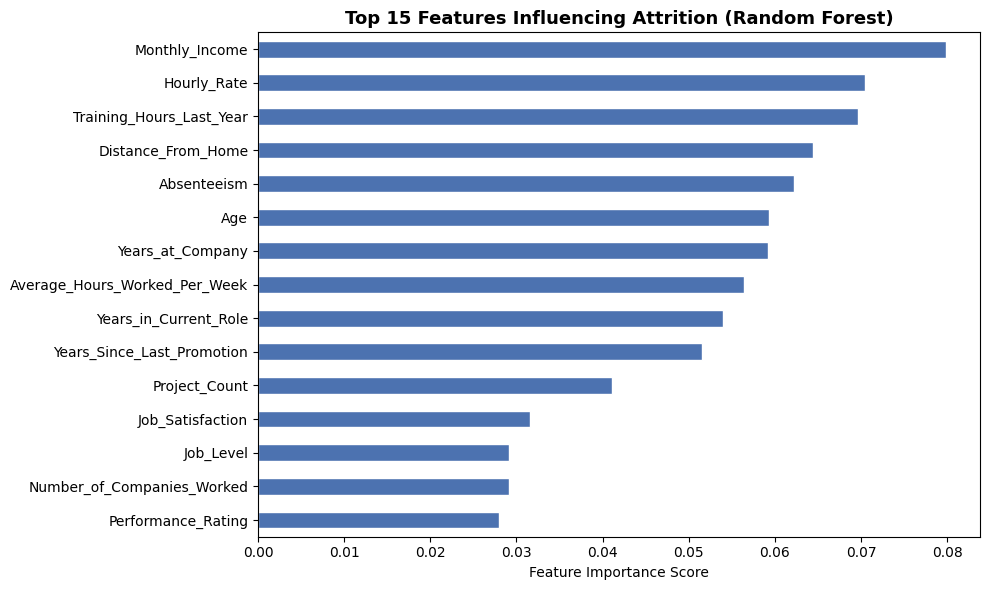

Top 5 attrition drivers:
  Monthly_Income: 0.0798
  Hourly_Rate: 0.0704
  Training_Hours_Last_Year: 0.0697
  Distance_From_Home: 0.0644
  Absenteeism: 0.0622


In [31]:
rf_model    = trained_models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind="barh", color="#4C72B0", edgecolor="white")
plt.title("Top 15 Features Influencing Attrition (Random Forest)", fontsize=13, fontweight="bold")
plt.xlabel("Feature Importance Score")
plt.tight_layout()
plt.show()

print("Top 5 attrition drivers:")
for feat, score in top_features.head(5).items():
    print(f"  {feat}: {score:.4f}")


### 7.2 High-Risk Employee Profile

In [32]:
X_all_scaled = scaler.transform(X)
df["Attrition_Predicted"]   = rf_model.predict(X_all_scaled)
df["Attrition_Probability"] = rf_model.predict_proba(X_all_scaled)[:, 1]

high_risk = df[df["Attrition_Predicted"] == 1].copy()
print(f"High-risk employees flagged: {len(high_risk)} out of {len(df)}")
print(f"\nHigh-Risk Profile Summary:")
print(f"  Average Age:            {high_risk['Age'].mean():.1f}")
print(f"  Overtime (Yes %):       {(high_risk['Overtime']=='Yes').mean()*100:.1f}%")
print(f"  Avg Monthly Income:     {high_risk['Monthly_Income'].mean():,.0f}")
print(f"  Avg Job Satisfaction:   {high_risk['Job_Satisfaction'].mean():.2f}")
print(f"  Avg Work-Life Balance:  {high_risk['Work_Life_Balance'].mean():.2f}")
print(f"  Avg Absenteeism:        {high_risk['Absenteeism'].mean():.1f} days")
print(f"  Avg Years at Company:   {high_risk['Years_at_Company'].mean():.1f}")


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


High-risk employees flagged: 145 out of 1000

High-Risk Profile Summary:
  Average Age:            40.4
  Overtime (Yes %):       43.4%
  Avg Monthly Income:     11,423
  Avg Job Satisfaction:   3.26
  Avg Work-Life Balance:  2.58
  Avg Absenteeism:        10.5 days
  Avg Years at Company:   15.6


### 7.3 Predicted Attrition Risk by Department

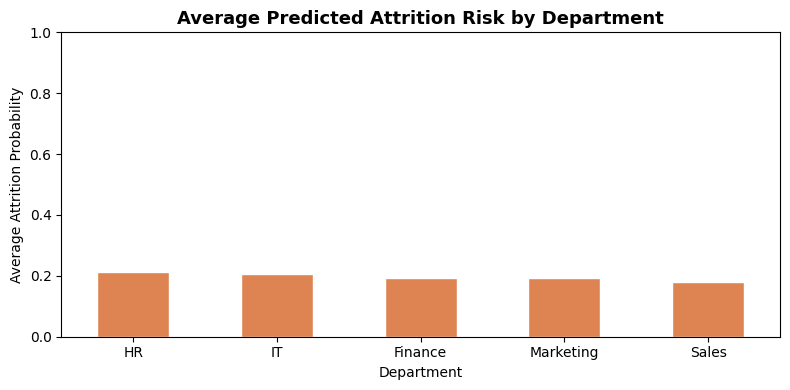

Predicted attrition risk by department:
Department
HR           0.212296
IT           0.206007
Finance      0.194074
Marketing    0.192945
Sales        0.179127


In [33]:
dept_risk = df.groupby("Department")["Attrition_Probability"].mean().sort_values(ascending=False)

dept_risk.plot(kind="bar", figsize=(8, 4), color="#DD8452", edgecolor="white")
plt.title("Average Predicted Attrition Risk by Department", fontsize=13, fontweight="bold")
plt.xlabel("Department")
plt.ylabel("Average Attrition Probability")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("Predicted attrition risk by department:")
print(dept_risk.to_string())


### 7.4 HR Intervention Strategies & Recommendations

Based on the actual EDA findings from this dataset, the following recommendations are made:

> ⚠️ **Note:** Several features commonly assumed to drive attrition (overtime, low income, low job satisfaction, poor WLB) showed weaker or unexpected relationships in this dataset. Recommendations below are grounded in what the data actually shows.

| What the Data Shows | Recommended HR Action |
|---|---|
| **IT and HR departments have highest attrition (~21%)** | Focus retention programmes on IT and HR first; investigate role-specific pressures through targeted surveys |
| **Attrition is spread evenly across departments (17–21%)** | Avoid one-size-fits-all solutions; use individual-level risk scores rather than department-wide assumptions |
| **Overtime shows no meaningful attrition difference (19.5% vs 18.2%)** | Overtime alone is not the signal — investigate qualitative factors like manager relationships and career growth |
| **Higher earners also leave (left median income > stayed)** | Compensation is not the primary retention lever here — focus on non-financial factors: growth, recognition, autonomy |
| **Job satisfaction has a non-linear relationship with attrition** | Satisfaction surveys should be combined with exit interview data to understand the full picture |
| **Absenteeism difference is small (0.67 days)** | Monitor trends over time rather than snapshot figures; sudden spikes matter more than absolute level |
| **Strongest model predictors: Monthly Income, Training Hours, Distance, Absenteeism** | Use these as inputs to a regular risk-scoring model; flag individuals above a threshold for HR check-in |

### Conclusion
The **Decision Tree** was the only model that predicted any attrition at all, due to severe class imbalance (81:19). All three models struggled because the dataset features do not strongly separate the two classes — correlations are weak across the board (max 0.056).

**Recommended next steps for a production-ready tool:**
- Apply SMOTE oversampling or class_weight='balanced' to improve minority class detection
- Collect more data — 189 attrition cases is a small sample for reliable model training
- Gather qualitative data (exit interview themes, manager ratings) to complement the numerical features
- Re-evaluate model performance quarterly as more attrition events accumulate